#📌 Extracción

In [64]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# Cargando datos desde la API en git
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()


# Normalizando el JSON anidado
df = pd.json_normalize(data)


# Mostrando las primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

In [65]:
#Info de dataframe
df.info()
#tipo de dato
print(df.dtypes)
#Columnas para churn, principales
principal_columns = ["gender", "SeniorCitizen", "Dependents", "tenure", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod", "Charges.Monthly", "Charges.Total", "Churn"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [69]:
#Eliminacion de prefijos
prefij = ["customer.", "phone.", "internet.", "account.", "Charges."]

#Lista, definicion - emparejamiento - mapeo
nombre_actual = []
nombre_limpio = []

#Iteracion en el dataframe
for col in df.columns:
    es_prefijo = False
    #Para verificar si la columna empieza por algun prefijo
    for prefijo in prefij:
        if col.startswith(prefijo):
            nombre_actual.append(col)
    #Eliminar el prefijo para un nombre limpio
            nombre_limpio.append(col.replace(prefijo, "",1))
            es_prefijo = True
            break
    # Mantener la columna igual si no posee el prefijo
    if not es_prefijo:
      nombre_actual.append(col)
      nombre_limpio.append(col)

#Creando el diccionario de mapeo: zip()   -  Emparejando nombre actual con limpio
mapeo_rnom = dict(zip(nombre_actual, nombre_limpio))

#Renombrando
df = df.rename(columns=mapeo_rnom)
df.info()




<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

#🔧 Transformación

In [70]:
#Manejo de valores vacíos en churn
df = df[df['Churn'] !=""]

#Manejando el no phone service y no internet como solo no
service_columns = ["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for col in service_columns:
  df[col] = df[col].replace({"No phone service": "No", "No internet service": "No"})
#Manipulando strings con lower case
for col in df.select_dtypes(include="object").columns:
  if col != "customerID":
    df[col] = df[col].str.lower().str.strip().str.replace(" ", "_")
#Duplicado
df.drop_duplicates(inplace=True)

In [71]:
df["Daily"] = df["Monthly"] / 30

In [72]:
binary_columns = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"] + service_columns
for col in binary_columns:
  df[col] = np.where(df[col].astype(str) == 'yes', 1, np.where(df[col].astype(str) == 'no', 0, np.nan))

#📊 Carga y análisis

In [73]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Monthly,Daily
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,3.958333


Churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


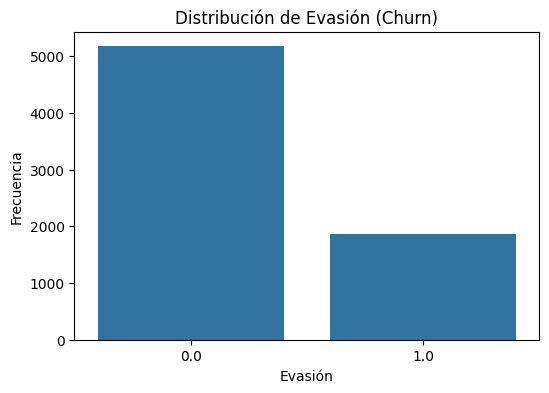

In [75]:
#Distribucion de evasion

churn_dist = (df['Churn'].value_counts(normalize=True) * 100)
print(churn_dist)


plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Distribución de Evasión (Churn)')
plt.xlabel('Evasión')
plt.ylabel('Frecuencia')
plt.show()

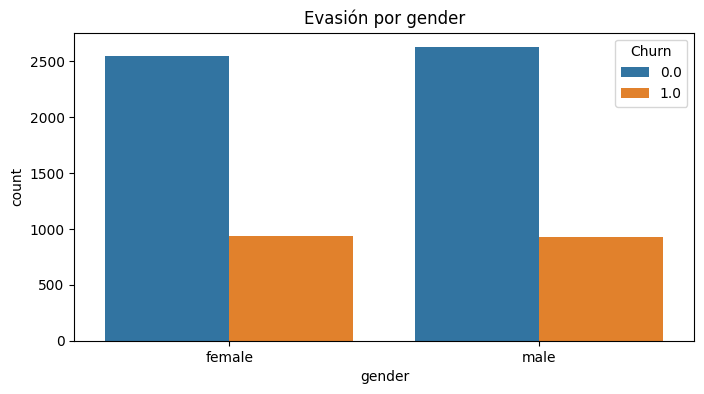

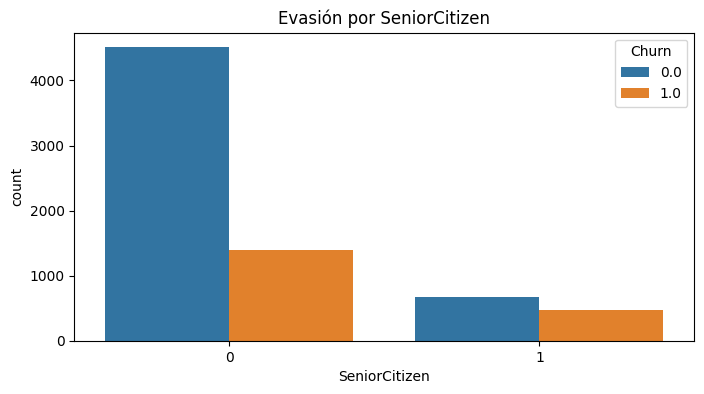

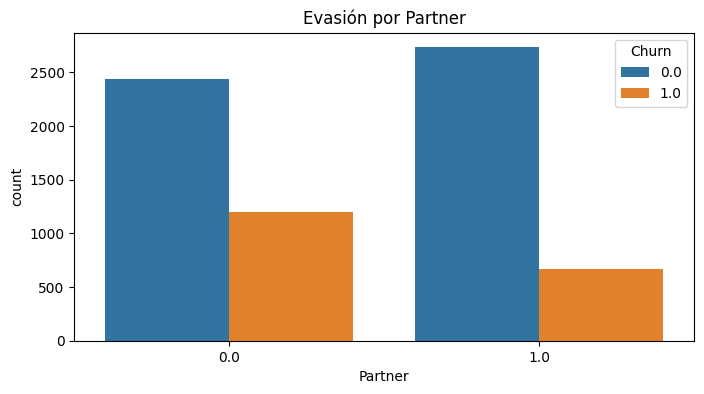

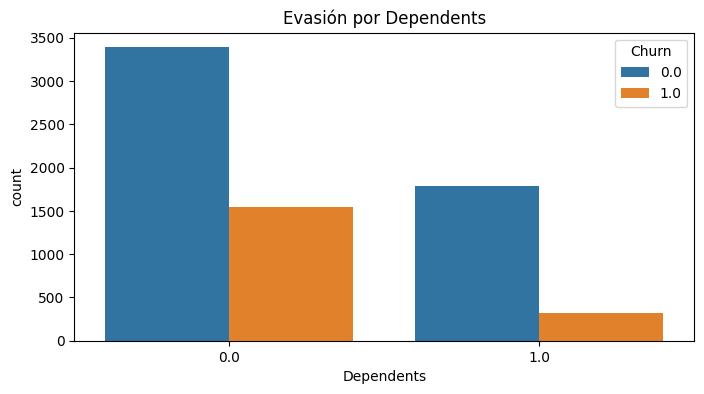

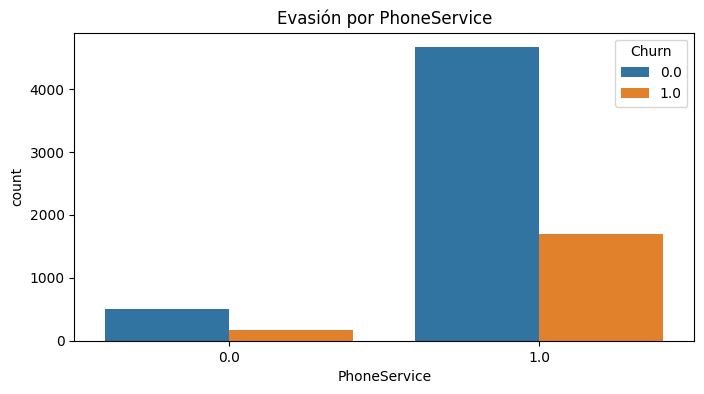

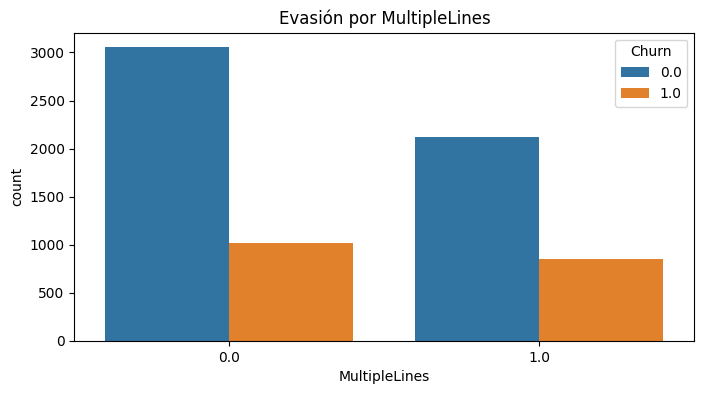

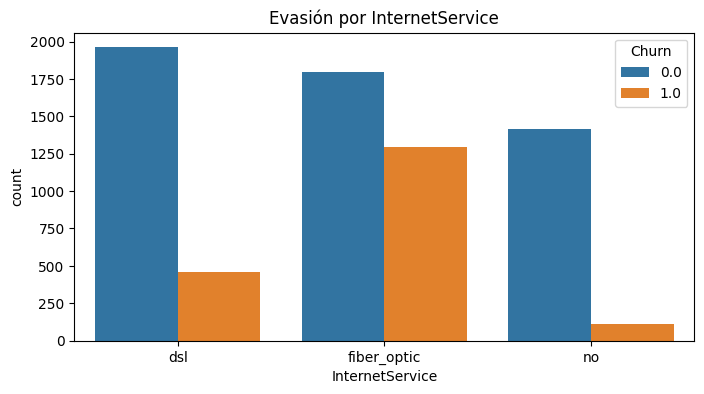

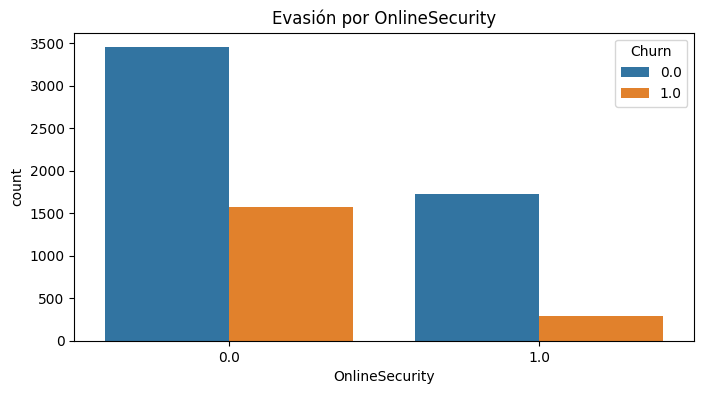

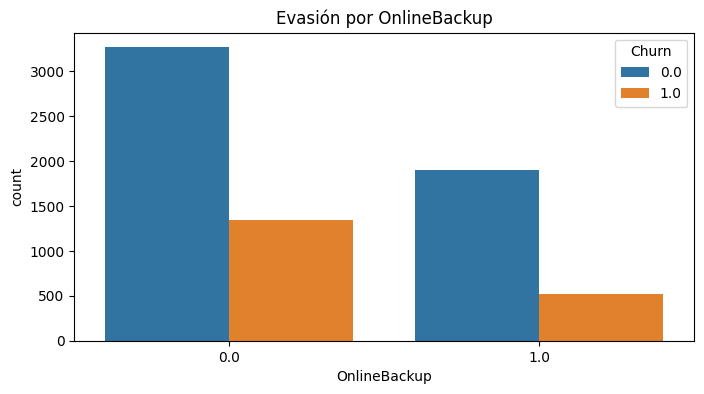

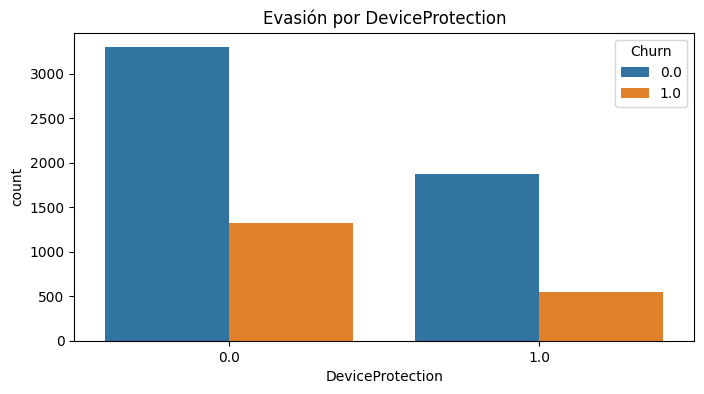

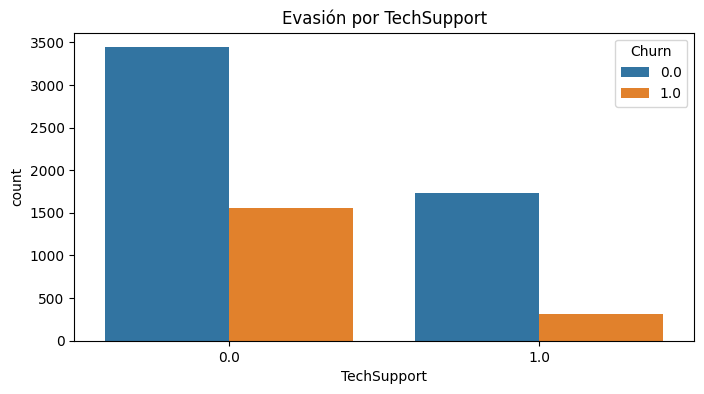

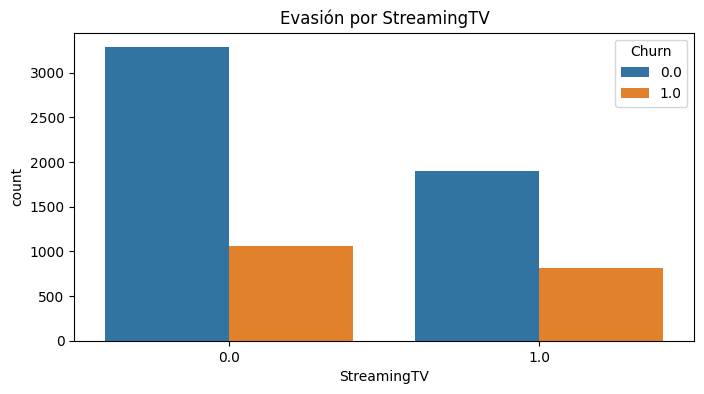

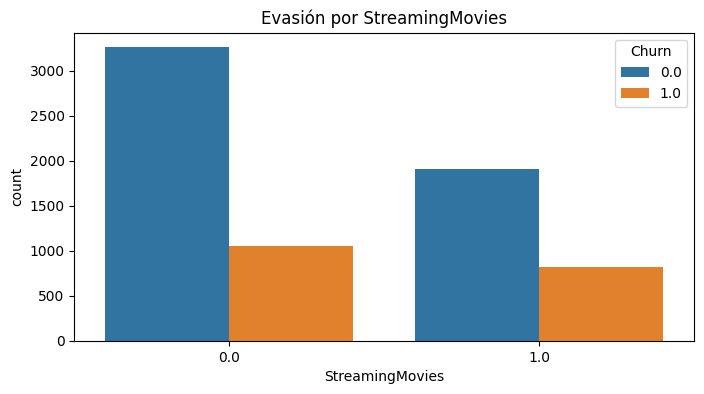

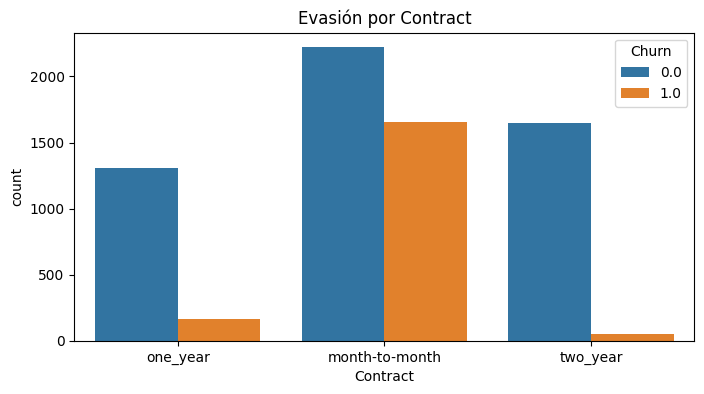

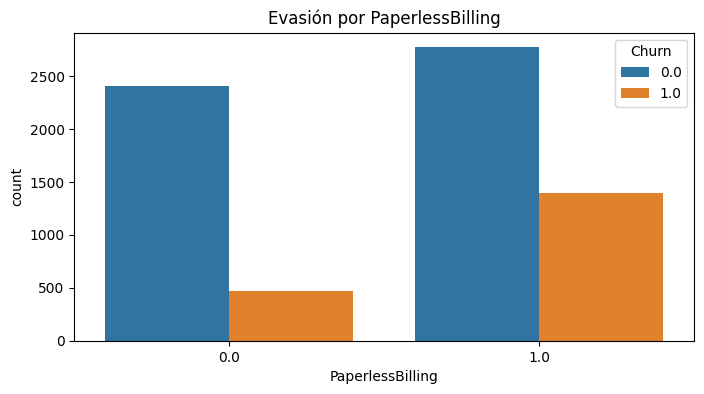

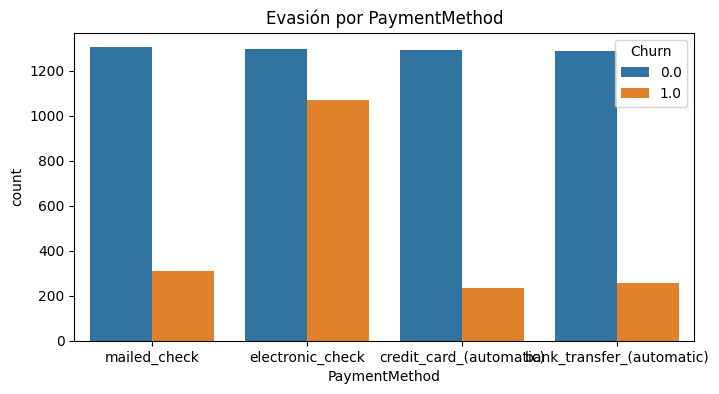

In [76]:
cat_vars = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

for var in cat_vars:
    plt.figure(figsize=(8,4))
    sns.countplot(x=var, hue='Churn', data=df)
    plt.title(f'Evasión por {var}')
    plt.show()

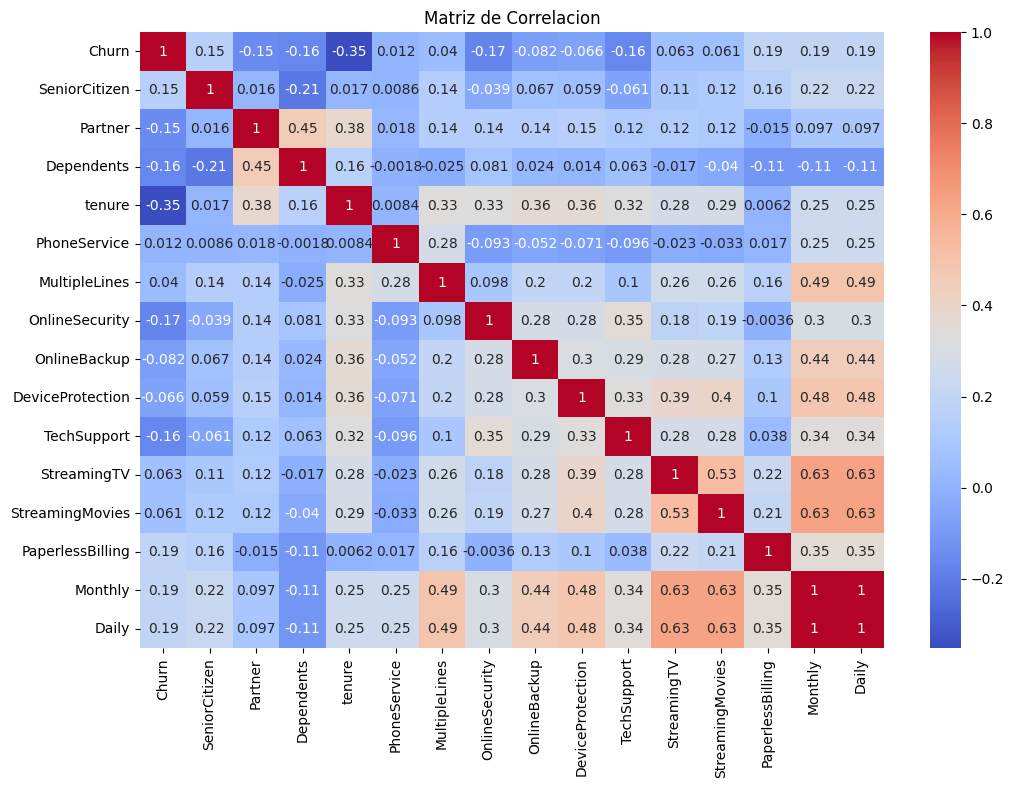

Churn               1.000000
Monthly             0.193356
Daily               0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
StreamingTV         0.063228
StreamingMovies     0.061382
MultipleLines       0.040102
PhoneService        0.011942
DeviceProtection   -0.066160
OnlineBackup       -0.082255
Partner            -0.150448
Dependents         -0.164221
TechSupport        -0.164674
OnlineSecurity     -0.171226
tenure             -0.352229
Name: Churn, dtype: float64


In [77]:
#Analisis de correllacion
corr_df = df.select_dtypes(include=["float64", "int64"])
corr_matrix = corr_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlacion')
plt.show()

print(corr_matrix["Churn"].sort_values(ascending=False))

#📄Informe final

El proposito de este analisis es determinar por que los clientes producen una alta tasa de cancelaciones. La empresa necesita comprender los factores que llevan a la pérdida de clientes.

De acuerdo con los gráficos sabemos que la tasa de evasion se acerca al 26%, los contraos son mas mensuales que anuales.
Los metodos de pago electronicos se asoccian con la evasion y los cargos totales reducen la evasion. Los ciudadanos mayores y dependientes aumentan la evasion, mientras que los servicios adicionales la disminnuyen o sea atraen a los clientes o evitan su cancelacion/evasion del servicio.

En base a la informacion se podrian ofrecer mayores descuenos a largo plazo para el plan anual por ejemplo. Mejorar la guia o soporte al client en forma de pago electrónico y monitorear los cargos mensuales para indentificar riesgos de cancelacion/abandono del servicio.